# [drosophila_body_orientation_predictor](https://github.com/nehalsinghmangat/drosophila_body_orientation_predictor) — Data Correction and Model Training

This notebook cleans, corrects, and augments the experimental data from [van Breugel et al. (2014)](https://www.sciencedirect.com/science/article/pii/S0960982213015820) to produce the fully preprocessed dataset used to train the heading predictor neural network.


## Data Correction and Processing

The augmentation and correction pipeline proceeds through the following stages, saving intermediate outputs to `../pipelinedata/`:

1. **`01_merged/`** — Raw Parquet files merged across wind speeds (30/40/60 cm/s)
2. **`02_augmented/`** — Kinematic features added (groundspeed, airspeed, thrust, acceleration)
3. **`03_corrected/`** — 180° heading ambiguities resolved via a single thrust-referenced, weighted, outlier-robust naive correction (`naive_heading_correction_v2`) — no convex optimization, no MOSEK dependency
4. **`04_filtered/`** — Short or uncorrectable trajectories removed
5. **`05_final/`** — Output columns (`heading_angle_x`, `heading_angle_y`) added; ready for model training

There is no separate smoothing stage: `naive_heading_correction_v2` already includes single-frame outlier interpolation, and the corrected trajectories are smooth enough without an additional Savitzky-Golay pass.

Neural network training is handled later in this same notebook.

## Methods


### Data Preparation and Preprocessing

We use data from [van Breugel et al. (2014)](https://doi.org/10.1242/jeb.098665), collected across three constant-wind conditions (30, 40, 60 cm/s). Two data streams are merged per trajectory: (i) flight trajectory (x/y position and velocity) and (ii) body-orientation measurements captured as ellipse parameters. Trajectories shorter than a minimum duration are discarded to ensure adequate temporal context for model training.

Below, we load the raw Parquet files for each wind speed, correct the airspeed reference frame, standardize field names, synchronize timestamps, and merge the two streams into a single CSV per wind speed.

In [ ]:
import os
import sys
import pandas as pd
import datetime

sys.path.insert(0, os.path.abspath('../utils'))

from utils import (
    correct_for_wind,
    remove_irrelevant_trajectory_data,
    remove_irrelevant_body_data,
    sync_time,
    join_all_body_and_trajec_df,
    transform_timestamps_to_start_at_zero,
)

In [ ]:

windspeeds = ["30cms", "40cms", "60cms"]
for windspeed in windspeeds:
    trajec_df = pd.read_parquet(f"../experimentaldata/{windspeed}/flight_trajectories_3d_HCS_odor_horizon_matched.parquet")
    body_df = pd.read_parquet(f"../experimentaldata/{windspeed}/body_orientations_HCS_odor_horizon_matched.parquet")
    key_table = pd.read_parquet(f"../experimentaldata/{windspeed}/body_trajec_matches.parquet")

    trajec_df = correct_for_wind(trajec_df)
    trajec_df = remove_irrelevant_trajectory_data(trajec_df)
    body_df = remove_irrelevant_body_data(body_df)

    synced_trajectory = sync_time(trajec_df)
    synced_body = sync_time(body_df)

    body_and_trajectory = join_all_body_and_trajec_df(synced_body, synced_trajectory, key_table)
    body_and_trajectory = [transform_timestamps_to_start_at_zero(t) for t in body_and_trajectory]
    body_and_trajectory = [t for t in body_and_trajectory if len(t) > 12]

    temp_fly_data = pd.concat(body_and_trajectory, ignore_index=True)
    os.makedirs(f"../pipelinedata/01_merged/{windspeed}", exist_ok=True)
    temp_fly_data.to_csv(f"../pipelinedata/01_merged/{windspeed}/fly_trajectories_with_body_orientations.csv", index=False)

temp_file_paths = [
    "../pipelinedata/01_merged/30cms/fly_trajectories_with_body_orientations.csv",
    "../pipelinedata/01_merged/40cms/fly_trajectories_with_body_orientations.csv",
    "../pipelinedata/01_merged/60cms/fly_trajectories_with_body_orientations.csv",
]
temp_dfs = [pd.read_csv(f) for f in temp_file_paths]
heading_and_trajectories = pd.concat(temp_dfs, ignore_index=True)
heading_and_trajectories.to_csv('../pipelinedata/01_merged/all_wind_heading_and_trajectories.csv', index=False)

Visualize the data

In [ ]:
all_fly_data = pd.read_csv('../pipelinedata/01_merged/all_wind_heading_and_trajectories.csv')
all_fly_data.head()

#### Kinematic Feature Augmentation

We augment each merged trajectory with physically meaningful derived quantities: groundspeed, airspeed, linear acceleration, and thrust (magnitude and angle). These fields are required both for heading correction (thrust angle serves as a reference direction) and as inputs to the neural network. The heading angle is also initialized here from the ellipse short-axis angle (accurate only modulo π — corrected in the next step).


In [ ]:
import os
import pynumdiff as pynd
import numpy as np

from utils import augment_fly_trajectory

In [ ]:
all_fly_data = pd.read_csv('../pipelinedata/01_merged/all_wind_heading_and_trajectories.csv')
body_and_trajectory_by_id = [group for _, group in all_fly_data.groupby('trajec_objid')]

temp_augmented_all_fly_data = [augment_fly_trajectory(df, compute_heading_from_ellipses=True) for df in body_and_trajectory_by_id]
augmented_all_fly_data = pd.concat(temp_augmented_all_fly_data, ignore_index=True)
os.makedirs('../pipelinedata/02_augmented', exist_ok=True)
augmented_all_fly_data.to_csv('../pipelinedata/02_augmented/all_wind_heading_and_trajectories_augmented.csv', index=False)

#### Body Orientation Correction and Filtering

The body-orientation measurements were captured with a top-down camera. At each frame, the fly was approximated as an ellipse, so the recorded heading is only accurate modulo π. This produces discontinuous π-jumps throughout many trajectories, and measurement noise occasionally corrupts a single frame outright.

We apply one correction step (below) and then filter out any trajectory that still retains an uncorrectable jump.

##### Naïve Heading Correction (thrust-referenced, weighted, outlier-robust)

The body-orientation measurements are only accurate modulo π (the ellipse fit cannot distinguish head from tail), producing discontinuous π-jumps throughout many trajectories. `naive_heading_correction_v2` resolves these in three steps:

1. Aligns the initial heading with the **thrust direction** (not groundspeed direction — thrust stays well-defined even when the fly is nearly stationary and groundspeed direction becomes numerically unstable).
2. Uses `np.unwrap` (period π) to detect and remove π-flips locally, frame by frame.
3. A single-frame outlier in that locally-unwrapped signal — a lone frame that deviates sharply from both neighbors while those neighbors are close to each other, distinguishing an isolated bad measurement from a genuine fast turn — is detected and linearly interpolated.

Both global branch decisions (steps 1 and the final whole-trajectory alignment) use a thrust-magnitude-**weighted** circular mean, so low-thrust (noisier) frames contribute less than high-thrust (more reliable) ones.

This replaces the original naive+convex-optimization two-step correction: the convex-optimization step was found to introduce spurious local jumps and to reject ~1000 otherwise-usable trajectories without a principled reason (MOSEK dependency, and its rejections did not correlate with genuine data quality).

In [ ]:
from utils import naive_heading_correction_v2

##### Visualizing Heading Correction Steps

For troubleshooting and sanity-checking, we visualize a sample of trajectories before and after correction to confirm the algorithm is behaving as expected.

In [ ]:
import os
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
augmented_all_fly_data = pd.read_csv('../pipelinedata/02_augmented/all_wind_heading_and_trajectories_augmented.csv')
heading_and_trajectory_by_id = [group for _, group in augmented_all_fly_data.groupby('trajec_objid')]

In [ ]:
from utils import plot_trajectory

In [ ]:
import gc

# Loop through EVERY trajectory and create/save figures (no sampling -- for full manual review)
for trajectory in heading_and_trajectory_by_id:
    trajec_objid = trajectory["trajec_objid"].iloc[0]

    # Create the subplots with a reduced dpi and adjusted size
    fig, axs = plt.subplots(1, 2, figsize=(8, 10), dpi=100)

    # Plot the original (raw) trajectory
    plot_trajectory(axs[0], trajectory)

    # Apply the corrected heading and plot
    corrected = naive_heading_correction_v2(trajectory.copy())
    plot_trajectory(axs[1], corrected)

    # Save the figure as an SVG file
    os.makedirs('../pipelinedata/03_corrected/heading_correction_steps_svg', exist_ok=True)
    svg_filename = f'../pipelinedata/03_corrected/heading_correction_steps_svg/{trajec_objid}.svg'
    plt.savefig(svg_filename, format='svg')

    # Close the figure to free up memory
    plt.close(fig)

    # Explicitly call garbage collection to free memory
    gc.collect()

##### Applying Heading Correction to All Trajectories

We apply the correction to every trajectory and save the result.

In [ ]:
import os

augmented_all_fly_data = pd.read_csv('../pipelinedata/02_augmented/all_wind_heading_and_trajectories_augmented.csv')
body_and_trajectory_by_id = [group for _, group in augmented_all_fly_data.groupby('trajec_objid')]
temp_dfs = []
for traj in body_and_trajectory_by_id:
    corrected_trajec = naive_heading_correction_v2(traj.copy())
    temp_dfs.append(corrected_trajec)
corrected_aug_all_fly_data = pd.concat(temp_dfs, ignore_index=True)
os.makedirs('../pipelinedata/03_corrected', exist_ok=True)
corrected_aug_all_fly_data.to_csv('../pipelinedata/03_corrected/all_wind_heading_and_trajectories_augmented_corrected.csv', index=False)

##### Trajectory Filtering

Some trajectories retain residual π-flips that neither correction step fully resolves. We detect these by computing the circular distance between consecutive heading angles and filtering out trajectories that exceed a threshold jump magnitude.


In [ ]:
from utils import circular_distance, calc_circular_difference

In [ ]:
import os

# Load the CSV file
corrected_aug_all_fly_data = pd.read_csv('../pipelinedata/03_corrected/all_wind_heading_and_trajectories_augmented_corrected.csv')

# Group data by 'trajec_objid'
body_and_trajectory_by_id = [group for _, group in corrected_aug_all_fly_data.groupby('trajec_objid')]

# Initialize lists for storing filtered and removed trajectories
temp_dfs = []
temp_bad_dfs = []
removal_count = 0

# Loop through each trajectory and apply filtering based on circular difference
for traj in body_and_trajectory_by_id:
   circ_diff_data = calc_circular_difference(traj)  # Ensure this function returns a DataFrame with 'circ_dist_diff'
   if max(circ_diff_data["circ_dist_diff"]) < (np.pi / 2):  # Filter condition
      temp_dfs.append(traj)  # Keep this trajectory
   else:
      temp_bad_dfs.append(traj)  # Mark this trajectory for removal
      removal_count += 1

# Concatenate the filtered and removed trajectories into separate DataFrames
bad_all_fly_data = pd.concat(temp_bad_dfs, ignore_index=True)
filtered_corr_aug_all_fly_data = pd.concat(temp_dfs, ignore_index=True)

os.makedirs('../pipelinedata/04_filtered', exist_ok=True)

# Save the filtered data to CSV files
filtered_corr_aug_all_fly_data.to_csv('../pipelinedata/04_filtered/all_wind_heading_and_trajectories_augmented_corrected_filtered.csv', index=False)

# Save the rejected trajectories
bad_all_fly_data.to_csv('../pipelinedata/04_filtered/rejected_trajectories.csv', index=False)

# Print the total number of trajectories and the number of removals
print(f"Total trajectories: {len(body_and_trajectory_by_id)}")
print(f"Number of removed trajectories: {removal_count}")

##### Visualizing Filtered-Out Trajectories


In [ ]:
import random
import gc

rejected_trajectories = pd.read_csv('../pipelinedata/04_filtered/rejected_trajectories.csv')
body_and_trajectory_by_id = [group for _, group in rejected_trajectories.groupby('trajec_objid')]

# Set the random seed for repeatability
random.seed(42)

# Loop through each trajectory and create/save figures
for trajectory in body_and_trajectory_by_id:
    trajec_objid = trajectory["trajec_objid"].iloc[0]
    fig, ax = plt.subplots(figsize=(12, 12), dpi=150)

    plot_trajectory(ax, trajectory, plot_ellipses=False, every_nth=1)

    # Save the figure as an SVG file
    os.makedirs('../pipelinedata/04_filtered/rejected_trajectory_svgs', exist_ok=True)
    svg_filename = f'../pipelinedata/04_filtered/rejected_trajectory_svgs/{trajec_objid}.svg'
    plt.savefig(svg_filename, format='svg')
    plt.close(fig)  # Close the figure to free up memory
    gc.collect()

In [ ]:
rejected_trajectories = pd.read_csv('../pipelinedata/04_filtered/rejected_trajectories.csv')
body_and_trajectory_by_id = [group for _, group in rejected_trajectories.groupby('trajec_objid')]
bad_trajec_1 = rejected_trajectories.loc[rejected_trajectories["trajec_objid"]=="20121002_184808_1788"]
fig, axs = plt.subplots(1, 3, figsize=(12, 12), dpi=150)
plot_trajectory(axs[0],bad_trajec_1)
plot_trajectory(axs[1],bad_trajec_1)
plot_trajectory(axs[2],bad_trajec_1)
plt.show()

##### Visualizing Final Corrected & Filtered Trajectories

In [ ]:
filtered_all_fly_data = pd.read_csv('../pipelinedata/04_filtered/all_wind_heading_and_trajectories_augmented_corrected_filtered.csv')
body_and_trajectory_by_id = [group for _, group in filtered_all_fly_data.groupby('trajec_objid')]

In [ ]:
import random
import gc

# Set the random seed for repeatability
random.seed(42)

# Randomly sample 100 trajectories from heading_and_trajectory_by_id
sampled_trajectories = random.sample(body_and_trajectory_by_id, 100)

# Loop through each trajectory and create/save figures
for trajectory in sampled_trajectories:
    trajec_objid = trajectory["trajec_objid"].iloc[0]
    fig, ax = plt.subplots(figsize=(12, 12), dpi=150)

    plot_trajectory(ax, trajectory)

    # Save the figure as an SVG file
    os.makedirs('../pipelinedata/04_filtered/trajectory_svgs', exist_ok=True)
    svg_filename = f'../pipelinedata/04_filtered/trajectory_svgs/{trajec_objid}.svg'
    plt.savefig(svg_filename, format='svg')
    plt.close(fig)  # Close the figure to free up memory
    gc.collect()

##### Figure 1 Panel A

In [ ]:
import os, sys
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath('../utils'))
import pandas as pd
from utils import plot_trajectory
augmented_all_fly_data = pd.read_csv('../pipelinedata/02_augmented/all_wind_heading_and_trajectories_augmented.csv')
filtered_all_fly_data  = pd.read_csv('../pipelinedata/04_filtered/all_wind_heading_and_trajectories_augmented_corrected_filtered.csv')

test_trajec = augmented_all_fly_data.loc[augmented_all_fly_data["trajec_objid"] == "20130327_193200_13850"]
corr_trajec = filtered_all_fly_data.loc[filtered_all_fly_data["trajec_objid"] == "20130327_193200_13850"]

fig, axs = plt.subplots(1, 2, figsize=(12, 12), dpi=150)
plot_trajectory(axs[0], test_trajec, heading_color='red', heading_size=0.3,arrow_width=0.010,arrow_scale=0.7)
plot_trajectory(axs[1], corr_trajec, heading_color='red', heading_size=0.3,arrow_width=0.010,arrow_scale=0.7)

os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/fig_1_panel_A.svg', format='svg', bbox_inches='tight')
plt.show()

##### Figure 1 Panel B

In [ ]:
import os, sys
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath('../utils'))
import pandas as pd
from utils import plot_fly_inputs_stacked

augmented_all_fly_data = pd.read_csv('../pipelinedata/02_augmented/all_wind_heading_and_trajectories_augmented.csv')
panel_b_trajec = augmented_all_fly_data.loc[augmented_all_fly_data["trajec_objid"] == "20130327_193200_13850"]

fig, axes = plt.subplots(6, 1, figsize=(10, 8), dpi=150, sharex=True)
plot_fly_inputs_stacked(panel_b_trajec, axes=axes)
fig.tight_layout()

os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/fig_1_panel_B.svg', format='svg', bbox_inches='tight')
plt.show()

##### Figure 1 Panel C

In [ ]:
import os, sys
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import numpy as np
sys.path.insert(0, os.path.abspath('../utils'))
import pandas as pd
from utils import make_color_map

filtered_all_fly_data = pd.read_csv('../pipelinedata/04_filtered/all_wind_heading_and_trajectories_augmented_corrected_filtered.csv')

heading  = filtered_all_fly_data['heading_angle'].values
gs_angle = filtered_all_fly_data['groundspeed_angle'].values
as_angle = filtered_all_fly_data['airspeed_angle'].values

cmap = make_color_map(color_list=['white', 'navy', 'cornflowerblue', 'aqua', 'yellow', 'red', 'darkred'], N=256)

PI_TICKS  = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
PI_LABELS = [r'$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']

def wrap_to_2pi(a):
    return a % (2 * np.pi)

def plot_scatter_heatmap_with_marginals(ax_main, ax_top, ax_right, x_data, y_data,
                                        x_label, y_label, n_bins=128, cmap=None,
                                        show_ylabel=True):
    if cmap is None:
        cmap = make_color_map(color_list=['white', 'navy', 'cornflowerblue', 'aqua', 'yellow', 'red', 'darkred'], N=256)
    x_data = wrap_to_2pi(x_data)
    y_data = wrap_to_2pi(y_data)
    angle_range = [[0, 2*np.pi], [0, 2*np.pi]]
    h, xedges, yedges = np.histogram2d(x_data, y_data, bins=n_bins, range=angle_range)
    h_masked = np.ma.masked_where(h.T == 0, h.T)
    norm = mcolors.LogNorm(vmin=1, vmax=h.max())
    im = ax_main.pcolormesh(xedges, yedges, h_masked, norm=norm, cmap=cmap)
    ax_main.plot([0, 2*np.pi], [0, 2*np.pi], 'w--', lw=0.6, alpha=0.4)
    ax_main.set_xlim(0, 2*np.pi)
    ax_main.set_ylim(0, 2*np.pi)
    ax_main.set_xticks(PI_TICKS)
    ax_main.set_xticklabels(PI_LABELS)
    ax_main.set_yticks(PI_TICKS)
    ax_main.set_yticklabels(PI_LABELS if show_ylabel else ['']*len(PI_TICKS))
    ax_main.set_xlabel(x_label, fontsize=10)
    if show_ylabel:
        ax_main.set_ylabel(y_label, fontsize=10)
    ax_main.spines['top'].set_visible(False)
    ax_main.spines['right'].set_visible(False)
    x_counts, x_bin_edges = np.histogram(x_data, bins=n_bins, range=(0, 2*np.pi))
    x_centers = 0.5 * (x_bin_edges[:-1] + x_bin_edges[1:])
    ax_top.fill_between(x_centers, x_counts, step='mid', color='steelblue', alpha=0.7, lw=0)
    ax_top.set_xlim(0, 2*np.pi)
    ax_top.set_xticks([])
    ax_top.set_yticks([])
    for spine in ax_top.spines.values():
        spine.set_visible(False)
    y_counts, y_bin_edges = np.histogram(y_data, bins=n_bins, range=(0, 2*np.pi))
    y_centers = 0.5 * (y_bin_edges[:-1] + y_bin_edges[1:])
    ax_right.fill_betweenx(y_centers, y_counts, step='mid', color='steelblue', alpha=0.7, lw=0)
    ax_right.set_ylim(0, 2*np.pi)
    ax_right.set_xticks([])
    ax_right.set_yticks([])
    for spine in ax_right.spines.values():
        spine.set_visible(False)
    return im

fig = plt.figure(figsize=(11, 5))
outer = gridspec.GridSpec(1, 3, figure=fig, wspace=0.1, width_ratios=[10, 10, 0.4])

gs1 = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[0],
    width_ratios=[4, 1], height_ratios=[1, 4], hspace=0.05, wspace=0.05)
ax1_top   = fig.add_subplot(gs1[0, 0])
ax1_main  = fig.add_subplot(gs1[1, 0])
ax1_right = fig.add_subplot(gs1[1, 1])
fig.add_subplot(gs1[0, 1]).axis('off')

gs2 = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer[1],
    width_ratios=[4, 1], height_ratios=[1, 4], hspace=0.05, wspace=0.05)
ax2_top   = fig.add_subplot(gs2[0, 0])
ax2_main  = fig.add_subplot(gs2[1, 0])
ax2_right = fig.add_subplot(gs2[1, 1])
fig.add_subplot(gs2[0, 1]).axis('off')

gs_cbar = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[2],
    height_ratios=[1, 4], hspace=0.05)
ax_cbar = fig.add_subplot(gs_cbar[1, 0])

im1 = plot_scatter_heatmap_with_marginals(
    ax1_main, ax1_top, ax1_right,
    gs_angle, heading, 'Groundspeed direction (rad)', 'Heading (rad)', cmap=cmap, show_ylabel=True)
im2 = plot_scatter_heatmap_with_marginals(
    ax2_main, ax2_top, ax2_right,
    as_angle, heading, 'Airspeed direction (rad)', 'Heading (rad)', cmap=cmap, show_ylabel=False)

cbar = fig.colorbar(im2, cax=ax_cbar, label='Count (log scale)')
cbar.ax.yaxis.label.set_size(10)

os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/fig_1_panel_C.svg', format='svg', bbox_inches='tight')
plt.show()

### Feature Augmentation, Rotation Augmentation, and Delay Embedding

To construct inputs for the neural network, we augment the processed trajectories with a time-delay embedding of six kinematic variables: groundspeed, groundspeed angle, airspeed, airspeed angle, thrust, and thrust angle. A backward-looking window of $W = 4$ timesteps yields $6 \times 4 = 24$ input features per training example. The target output is the heading direction represented as $(\cos\theta_t, \sin\theta_t)$, stored as `heading_angle_x` and `heading_angle_y`.

Note: rotation augmentation (randomly rotating all angular quantities per trajectory to remove wind-direction bias) was applied in the CEM model variant (`model_CEM_all-angle-rotate.keras`) but is not included in the base model trained here.


#### Import Preprocessed Data

Import the fully preprocessed dataset (corrected, filtered) and add the `heading_angle_x`/`heading_angle_y` output columns. There is no separate smoothing stage — `naive_heading_correction_v2` already includes outlier interpolation, and the filtered trajectories are used directly.

In [ ]:
import os
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np

final_all_fly_data = pd.read_csv('../pipelinedata/04_filtered/all_wind_heading_and_trajectories_augmented_corrected_filtered.csv')
final_all_fly_data['heading_angle_x'] = np.cos(final_all_fly_data['heading_angle'])
final_all_fly_data['heading_angle_y'] = np.sin(final_all_fly_data['heading_angle'])
os.makedirs('../pipelinedata/05_final', exist_ok=True)
final_all_fly_data.to_csv('../pipelinedata/05_final/all_wind_heading_and_trajectories_augmented_corrected_filtered_headx_heady.csv', index=False)

## Model Training


### Motivating an ANN

Before training a neural network, it is worth asking whether a much simpler model already
solves the problem. We fit ordinary least-squares (OLS) baselines directly on the three
physical kinematic quantities available at each frame — thrust, airspeed, and groundspeed —
individually and in combination, in two forms:

- **linear** — regress `heading_angle_x`/`heading_angle_y` on the raw Cartesian components
  of each quantity (e.g. `thrust * cos(thrust_angle)`, `thrust * sin(thrust_angle)`), so
  both magnitude and direction enter linearly.
- **circular** — regress the same two targets on only the unit-direction of each quantity
  (`cos(angle)`, `sin(angle)`), discarding magnitude entirely (the standard degree-1
  trigonometric-polynomial formulation for circular-circular regression).

All models are fit on a trajectory-grouped training split (no trajectory contributes frames
to both train and test) and evaluated on the same held-out test trajectories, split further
by flight-direction regime (upwind / crosswind / downwind, classified from the true heading
relative to the wind axis).

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from itertools import combinations
from sklearn.model_selection import GroupShuffleSplit

from utils import circular_distance

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

final_all_fly_data = pd.read_csv('../pipelinedata/05_final/all_wind_heading_and_trajectories_augmented_corrected_filtered_headx_heady.csv')
print(f"{len(final_all_fly_data)} frames, {final_all_fly_data['trajec_objid'].nunique()} trajectories")

# Trajectory-grouped train/test split -- no trajectory appears on both sides
traj_ids = final_all_fly_data['trajec_objid'].unique()
gss = GroupShuffleSplit(n_splits=1, test_size=0.33, random_state=RANDOM_SEED)
dummy_X = np.zeros((len(traj_ids), 1))
train_idx, test_idx = next(gss.split(dummy_X, groups=traj_ids))
train_ids = set(traj_ids[train_idx])
test_ids = set(traj_ids[test_idx])
train_df = final_all_fly_data[final_all_fly_data['trajec_objid'].isin(train_ids)].reset_index(drop=True)
test_df = final_all_fly_data[final_all_fly_data['trajec_objid'].isin(test_ids)].reset_index(drop=True)
print(f"Train: {len(train_df)} frames ({len(train_ids)} trajectories)")
print(f"Test:  {len(test_df)} frames ({len(test_ids)} trajectories)")

113738 frames, 3336 trajectories
Train: 76304 frames (2235 trajectories)
Test:  37434 frames (1101 trajectories)


In [2]:
quantities = {
    'thrust': ('thrust', 'thrust_angle'),
    'air': ('airspeed', 'airspeed_angle'),
    'ground': ('groundspeed', 'groundspeed_angle'),
}


def design_matrix(d, combo, kind):
    cols, names = [], []
    for q in combo:
        mag_col, ang_col = quantities[q]
        if kind == 'linear':
            cols += [d[mag_col].values * np.cos(d[ang_col].values),
                      d[mag_col].values * np.sin(d[ang_col].values)]
            names += [f'{q}_x', f'{q}_y']
        else:  # circular
            cols += [np.cos(d[ang_col].values), np.sin(d[ang_col].values)]
            names += [f'{q}_cos', f'{q}_sin']
    return pd.DataFrame(np.column_stack(cols), columns=names)


def fit_ols_baseline(train_d, test_d, combo, kind):
    Xtr = sm.add_constant(design_matrix(train_d, combo, kind))
    Xte = sm.add_constant(design_matrix(test_d, combo, kind), has_constant='add')
    model_x = sm.OLS(train_d['heading_angle_x'].values, Xtr).fit()
    model_y = sm.OLS(train_d['heading_angle_y'].values, Xtr).fit()
    pred_xy = np.column_stack([model_x.predict(Xte), model_y.predict(Xte)])
    return pred_xy


def angular_error_deg(y_true_xy, y_pred_xy):
    true_angle = np.arctan2(y_true_xy[:, 1], y_true_xy[:, 0])
    pred_angle = np.arctan2(y_pred_xy[:, 1], y_pred_xy[:, 0])
    return np.degrees(circular_distance(true_angle, pred_angle))


def classify_direction(angle_rad):
    # Project convention: positive x = upwind, wind heading = negative x direction.
    deg = np.degrees(np.arctan2(np.sin(angle_rad), np.cos(angle_rad)))
    return np.where(
        np.abs(deg) <= 45, 'upwind',
        np.where(np.abs(np.abs(deg) - 180) <= 45, 'downwind', 'crosswind')
    )


regime = classify_direction(test_df['heading_angle'].values)
y_true = test_df[['heading_angle_x', 'heading_angle_y']].values

combos = [c for r in range(1, 4) for c in combinations(quantities.keys(), r)]
rows = []
for combo in combos:
    combo_label = '+'.join(combo)
    for kind in ['linear', 'circular']:
        pred_xy = fit_ols_baseline(train_df, test_df, combo, kind)
        err = angular_error_deg(y_true, pred_xy)
        per_frame = pd.DataFrame({'trajec_objid': test_df['trajec_objid'].values, 'err': err, 'regime': regime})
        per_traj_regime = per_frame.groupby(['regime', 'trajec_objid'])['err'].median().reset_index()
        overall_per_traj = per_frame.groupby('trajec_objid')['err'].median()
        row = {'model': f'{kind}: {combo_label}', 'overall': overall_per_traj.median()}
        for reg in ['upwind', 'crosswind', 'downwind']:
            row[reg] = per_traj_regime.loc[per_traj_regime['regime'] == reg, 'err'].median()
        rows.append(row)

ols_regime_table = pd.DataFrame(rows).sort_values('overall').reset_index(drop=True)
pd.set_option('display.width', 140)
print(ols_regime_table.to_string(index=False))
os.makedirs('../pipelinedata/05_final', exist_ok=True)
ols_regime_table.to_csv('../pipelinedata/05_final/ols_baselines_by_regime.csv', index=False)

                      model   overall     upwind  crosswind  downwind
         linear: thrust+air  9.914509  55.753323  33.742061  5.578776
  linear: thrust+air+ground  9.952172  48.870788  33.464239  5.294615
      linear: thrust+ground  9.988820  50.771355  33.929740  5.140940
circular: thrust+air+ground 10.183422  34.619504  33.849435  6.474696
       circular: air+ground 10.557251  35.292066  37.548600  6.515436
              circular: air 10.572634  46.053448  44.665688  6.409555
       circular: thrust+air 10.848567  45.874091  39.807893  7.127760
                linear: air 10.944150  56.296589  35.653003  5.629149
         linear: air+ground 11.068469  53.347126  35.493400  5.396579
             linear: ground 11.219829  60.357592  37.422769  5.498748
    circular: thrust+ground 12.713324  43.536761  38.337269  7.307998
           circular: ground 16.737941 112.474782  40.705507  7.740805
           circular: thrust 18.058905  64.203191  54.874552 11.413702
             linear:

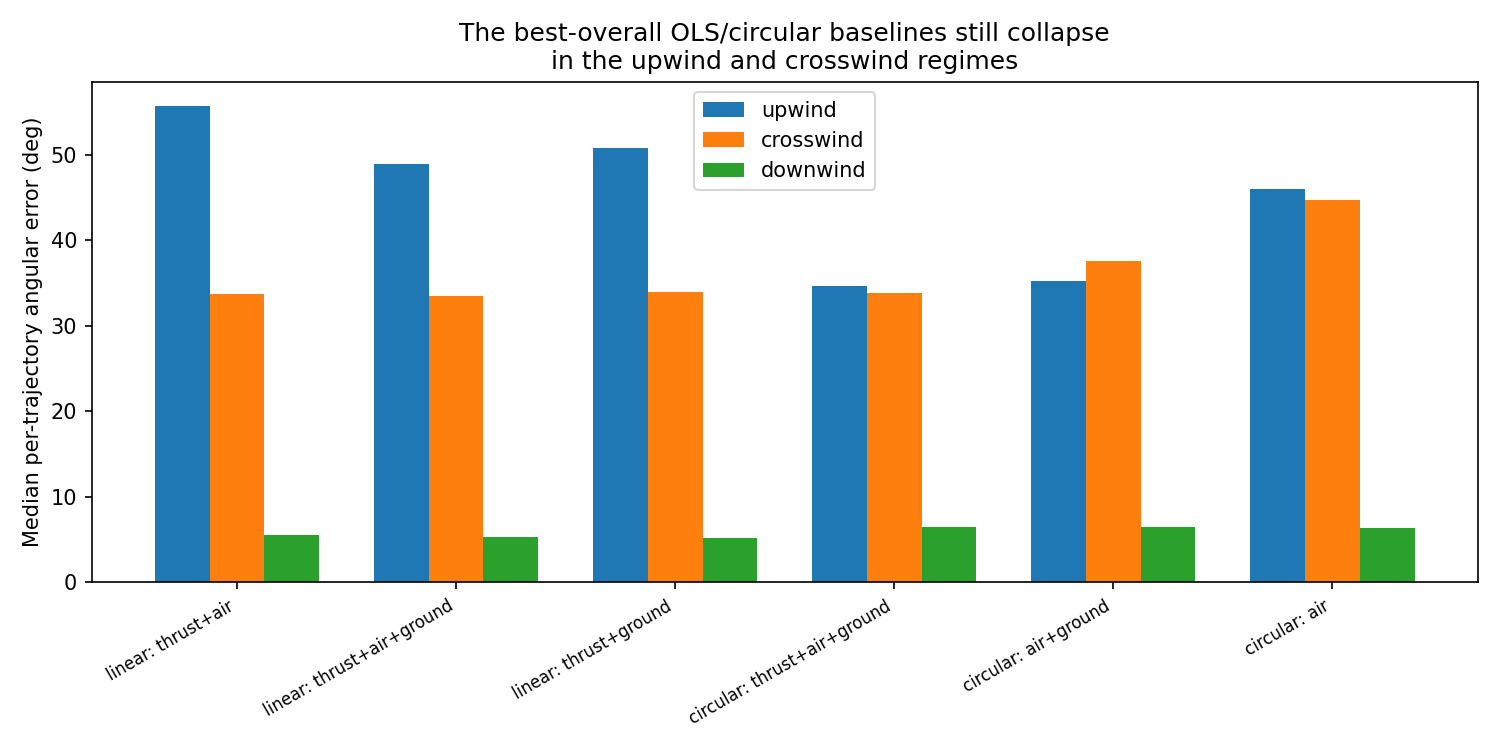

In [3]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
plot_models = ols_regime_table['model'].tolist()[:6]  # the 6 best-overall baselines
x = np.arange(len(plot_models))
width = 0.25

for i, regime_name in enumerate(['upwind', 'crosswind', 'downwind']):
    values = ols_regime_table.set_index('model').loc[plot_models, regime_name].values
    ax.bar(x + (i - 1) * width, values, width, label=regime_name)

ax.set_xticks(x)
ax.set_xticklabels(plot_models, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Median per-trajectory angular error (deg)')
ax.set_title('The best-overall OLS/circular baselines still collapse\nin the upwind and crosswind regimes')
ax.legend()
fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/motivating_ann_ols_by_regime.svg', format='svg')
plt.show()

**Significance:** Every OLS/circular baseline collapses in the upwind and crosswind regimes even when its POOLED error looks reasonable. The best overall baseline (linear thrust+air, 9.91 deg pooled) reaches 55.75 deg upwind and 33.74 deg crosswind, vs. just 5.58 deg downwind - a roughly 10x spread depending purely on which direction the fly happens to be heading. This is not a fluke of one baseline: every one of the 14 fits shows the same qualitative pattern, including the best circular fit (thrust+air+ground, 34.6 deg upwind / 33.8 deg crosswind / 6.5 deg downwind) and the worst (linear thrust alone, 115 deg upwind).

The mechanism is the same one identified when auditing this pipeline's regime-dependent difficulty more broadly: downwind is the regime where groundspeed magnitude is largest (a tailwind adds to the fly's forward airspeed), making groundspeed *direction* numerically well-determined; upwind and crosswind are where groundspeed can be small or dominated by drift, making its direction - and the OLS predictions built from it - unstable. No single fixed linear (or circular) combination of these three kinematic quantities can adapt its behavior to the regime it happens to be in.

This is the direct motivation for a neural network: a model with enough flexibility to learn a *different* effective mapping in each regime, rather than being forced to average across all of them with one fixed set of coefficients.

### Training the Model

We train the ANN on the same trajectory-grouped split used for the OLS baselines above, so
the comparison is apples-to-apples. Two deliberate simplifications relative to the model's
full feature set:

- **No thrust as an input.** The heading correction itself (`naive_heading_correction_v2`)
  is referenced against `thrust_angle`, so including thrust as a model input risks the same
  circularity concern reviewers raised about the original convex-optimization correction.
  It was also shown (separately) not to help accuracy once excluded correctly.
- **No time-delay embedding** (window = 1, current frame only). A sweep over window sizes
  (done in a separate notebook) found no consistent benefit from lagged frames once
  multi-seed noise is accounted for — window 1 performs equivalently to larger windows.

What remains: **wind-rotation augmentation**, applied only to the training trajectories
(after the split, never touching the held-out test trajectories) — each training trajectory
is duplicated with all angular quantities rotated by a random angle, teaching the model that
heading prediction should not depend on the arbitrary compass direction of the wind tunnel.

In [4]:
import random
import keras
from sklearn.model_selection import GroupShuffleSplit

from utils import pull_out_individual_trajectories, augment_with_time_delay_embedding, create_model

random.seed(RANDOM_SEED)

fly_traj_list = pull_out_individual_trajectories(final_all_fly_data, min_traj_length=12)
train_trajectories = [t for t in fly_traj_list if t['trajec_objid'].iloc[0] in train_ids]
test_trajectories = [t for t in fly_traj_list if t['trajec_objid'].iloc[0] in test_ids]
print(f"Train: {len(train_trajectories)} trajectories   Test: {len(test_trajectories)} trajectories")

TIME_WINDOW = 1
ann_input_names = ['groundspeed', 'groundspeed_angle', 'airspeed', 'airspeed_angle']
n_input = len(ann_input_names) * TIME_WINDOW
n_output = 2
KEEP_COLS = ['heading_angle_x', 'heading_angle_y', 'trajec_objid']


def embed(trajectories, time_window, wind_augment=False):
    kwargs = dict(time_window=time_window, input_names=ann_input_names,
                  output_names=KEEP_COLS, direction='backward')
    return augment_with_time_delay_embedding(
        trajectories, wind_augment=wind_augment, wrap_angles=wind_augment, **kwargs
    )


train_original = embed(train_trajectories, TIME_WINDOW, wind_augment=False)
train_wind = embed(train_trajectories, TIME_WINDOW, wind_augment=True)
train_all = pd.concat([train_original, train_wind], ignore_index=True)
test_embedded = embed(test_trajectories, TIME_WINDOW, wind_augment=False)

print(f"Train rows (original + rotated): {len(train_all):,}")
print(f"Test rows (unaugmented, held out): {len(test_embedded):,}")

Detected 3422 trajectories.
3340 trajectories with more than 12 timesteps.
Train: 2235 trajectories   Test: 1105 trajectories
Train rows (original + rotated): 152,240
Test rows (unaugmented, held out): 37,389


In [5]:
def grouped_inner_val_split(X, y, groups, val_fraction=0.2, seed=123):
    unique_groups = groups.unique()
    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_fraction, random_state=seed)
    dummy = np.zeros((len(unique_groups), 1))
    subtrain_gidx, val_gidx = next(gss2.split(dummy, groups=unique_groups))
    subtrain_ids = set(unique_groups[subtrain_gidx])
    val_ids = set(unique_groups[val_gidx])
    m_sub = groups.isin(subtrain_ids)
    m_val = groups.isin(val_ids)
    return (X[m_sub].values, y[m_sub].values), (X[m_val].values, y[m_val].values)


X_train = train_all.iloc[:, 0:n_input].reset_index(drop=True)
y_train = train_all[['heading_angle_x', 'heading_angle_y']].reset_index(drop=True)
groups_train = train_all['trajec_objid'].reset_index(drop=True)

keras.utils.set_random_seed(RANDOM_SEED)
(Xtr, ytr), (Xval, yval) = grouped_inner_val_split(X_train, y_train, groups_train)
model = create_model(n_input=n_input, n_output=n_output, neurons=15, layers=2)
model.fit(Xtr, ytr, validation_data=(Xval, yval), epochs=150, batch_size=256, verbose=0)
os.makedirs('../models', exist_ok=True)
model.save('../models/ann_wind_augmented_no_thrust_no_delay.keras')
print("Model trained and saved.")
print(f"Training rows: {len(Xtr):,}   Validation rows: {len(Xval):,}")

Model trained and saved.
Training rows: 122,328   Validation rows: 29,912


#### Evaluate on the held-out test set

In [6]:
def angular_error_deg(y_true_xy, y_pred_xy):
    true_angle = np.arctan2(y_true_xy[:, 1], y_true_xy[:, 0])
    pred_angle = np.arctan2(y_pred_xy[:, 1], y_pred_xy[:, 0])
    return np.degrees(circular_distance(true_angle, pred_angle))


def per_trajectory_errors(ids, err):
    return pd.DataFrame({'trajec_objid': ids, 'err': err}).groupby('trajec_objid')['err'].median()


def bootstrap_ci(values, n_boot=5000, ci=95, seed=0):
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    boots = rng.choice(values, size=(n_boot, len(values)), replace=True)
    boot_medians = np.median(boots, axis=1)
    lo, hi = np.percentile(boot_medians, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return float(np.median(values)), float(lo), float(hi)


X_test = test_embedded.iloc[:, 0:n_input].values
y_true_ann = test_embedded[['heading_angle_x', 'heading_angle_y']].values
pred = model.predict(X_test, verbose=0)
err = angular_error_deg(y_true_ann, pred)
per_traj = per_trajectory_errors(test_embedded['trajec_objid'].values, err)
med, lo, hi = bootstrap_ci(per_traj.values)
print(f"ANN (wind-augmented, no thrust, no time-delay), real held-out test set:")
print(f"  n_trajectories = {len(per_traj)}")
print(f"  median per-trajectory error = {med:.2f} deg  [95% CI {lo:.2f}, {hi:.2f}]")

ANN (wind-augmented, no thrust, no time-delay), real held-out test set:
  n_trajectories = 1099
  median per-trajectory error = 8.12 deg  [95% CI 7.70, 8.66]


#### Evaluate on the same upwind / crosswind / downwind regimes as the OLS baselines

In [7]:
heading_true = np.arctan2(y_true_ann[:, 1], y_true_ann[:, 0])
regime = classify_direction(heading_true)

ann_frame_df = pd.DataFrame({
    'trajec_objid': test_embedded['trajec_objid'].values,
    'err': err,
    'regime': regime,
})
ann_frame_df.to_csv('../pipelinedata/05_final/ann_by_regime.csv', index=False)

per_traj_regime = ann_frame_df.groupby(['regime', 'trajec_objid'])['err'].median().reset_index()
ann_regime_table = per_traj_regime.groupby('regime')['err'].median().reindex(['upwind', 'crosswind', 'downwind'])
ann_regime_table.name = 'ANN median per-trajectory error (deg)'
print(ann_regime_table.to_string())
print()
print(f"(Overall: {med:.2f} deg)")

regime
upwind       14.226172
crosswind    23.266354
downwind      7.525039

(Overall: 8.12 deg)


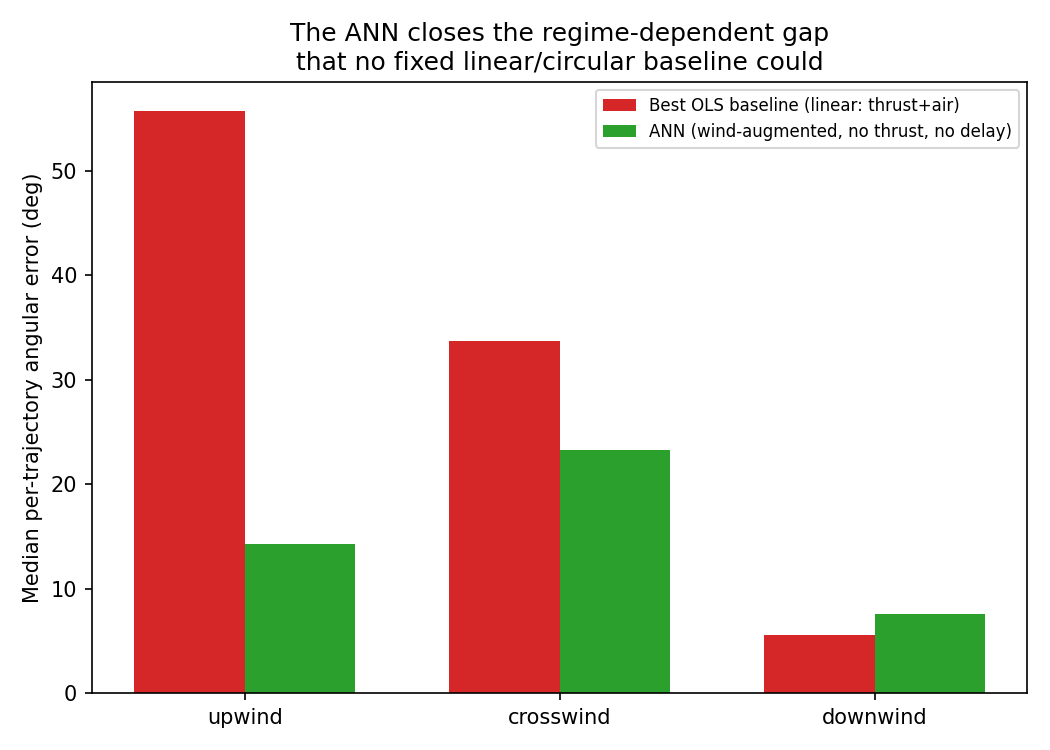

In [8]:
best_ols = ols_regime_table.iloc[0]  # already sorted by overall

fig, ax = plt.subplots(figsize=(7, 5), dpi=150)
regimes_order = ['upwind', 'crosswind', 'downwind']
x = np.arange(len(regimes_order))
width = 0.35
ols_vals = [best_ols[r] for r in regimes_order]
ann_vals = [ann_regime_table[r] for r in regimes_order]
ax.bar(x - width / 2, ols_vals, width, label=f"Best OLS baseline ({best_ols['model']})", color='tab:red')
ax.bar(x + width / 2, ann_vals, width, label='ANN (wind-augmented, no thrust, no delay)', color='tab:green')
ax.set_xticks(x)
ax.set_xticklabels(regimes_order)
ax.set_ylabel('Median per-trajectory angular error (deg)')
ax.set_title('The ANN closes the regime-dependent gap\nthat no fixed linear/circular baseline could')
ax.legend(fontsize=8)
fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/training_the_model_ann_vs_ols_by_regime.svg', format='svg')
plt.show()

**Significance:** The ANN roughly quarters the upwind error (14.23 deg vs. the best OLS baseline's 55.75 deg) and nearly halves the crosswind error (23.27 deg vs. 33.74 deg), while remaining competitive downwind (7.53 vs. 5.58 deg - the one regime every linear/circular baseline already handled well). The overall pooled number also improves (8.12 deg vs. 9.91 deg for the best OLS baseline), but that pooled comparison understates the real story: no fixed linear or circular combination of thrust/air/ground velocity can be *both* accurate downwind (where groundspeed direction is stable and informative) *and* accurate upwind/crosswind (where it degenerates) at the same time, because it is forced to use one fixed set of coefficients everywhere. The ANN, given the same non-thrust kinematic inputs (no time-delay embedding, so this is not extra temporal information either - just a genuinely different, regime-adaptive function), does not have that restriction.

This directly completes the motivation from the previous subsection: the case for a neural network here is not "it fits the average case slightly better," but "it is the only one of these approaches that stays usable across the fly's whole flight repertoire, rather than trading accuracy in the common (downwind) regime for near-total failure in the two regimes where the animal's own kinematic cues are intrinsically weaker."

### Visualizing All Trajectories

A full visual pass over every corrected trajectory, for manual review. Heading is drawn as a
red triangle (wedge) along the path; air velocity and thrust are drawn as blue and green
vectors respectively. Only every 4th frame is plotted (`every_nth=4`) to keep each figure
readable. All three colors/markers are parameters of `plot_trajectory` (`heading_color`
defaults to `'red'`; air velocity and thrust colors are currently hardcoded `'blue'`/`'green'`
inside the function) — change the defaults there, or pass the corresponding keyword arguments
here, to restyle these plots.

In [ ]:
import gc

from utils import plot_trajectory

body_and_trajectory_by_id = [group for _, group in final_all_fly_data.groupby('trajec_objid')]
print(f"Visualizing {len(body_and_trajectory_by_id)} trajectories...")

os.makedirs('../pipelinedata/05_final/trajectory_svgs', exist_ok=True)
for trajectory in body_and_trajectory_by_id:
    trajec_objid = trajectory["trajec_objid"].iloc[0]
    fig, ax = plt.subplots(figsize=(12, 12), dpi=100)

    plot_trajectory(ax, trajectory, plot_ellipses=False, every_nth=4)

    svg_filename = f'../pipelinedata/05_final/trajectory_svgs/{trajec_objid}.svg'
    plt.savefig(svg_filename, format='svg')
    plt.close(fig)
    gc.collect()

print("Done.")

### Prediction on External Data (David's Dataset)

The same qualitative check used to validate the original model (`model_training.ipynb`):
apply the trained estimator to David's independent trajectory dataset, where only
center-of-mass motion was recorded (no ellipse-based body orientation), and compare the
model's predicted heading (blue) against David's own recorded heading (red). This reuses
the same pre-augmented external data (`pipelinedata/external/david_data_augmented.csv`) and
the same `plot_trajectory_with_predicted_heading` wrapper as the original notebook — only the
model and its feature set differ (here: no thrust, no time-delay embedding), so this is a
direct, like-for-like comparison of how well each model's predictions generalize to data it
was never trained or corrected on.

In [9]:
import gc

import keras
from utils import plot_trajectory_with_predicted_heading

ann_model = keras.models.load_model('../models/ann_wind_augmented_no_thrust_no_delay.keras', safe_mode=False)
david_kwargs = dict(time_window=TIME_WINDOW, input_names=ann_input_names,
                     output_names=['heading_angle_x', 'heading_angle_y'], direction='backward')

David_fly_data = pd.read_csv('../pipelinedata/external/david_data_augmented.csv')
body_and_trajectory_by_id = [group for _, group in David_fly_data.groupby('trajec_objid')]
print(f"{len(body_and_trajectory_by_id)} David trajectories")

os.makedirs('../figures/external_data_predicted_heading_new_model', exist_ok=True)
for trajectory in body_and_trajectory_by_id:
    trajec_objid = trajectory["trajec_objid"].iloc[0]
    fig, ax = plt.subplots(figsize=(12, 12), dpi=150)
    plot_trajectory_with_predicted_heading(trajectory, ax, n_input, ann_model,
        include_id=True, nskip=4, smooth=True, **david_kwargs)

    svg_filename = f'../figures/external_data_predicted_heading_new_model/{trajec_objid}.svg'
    plt.savefig(svg_filename, format='svg')
    plt.close(fig)
    gc.collect()

3 David trajectories


#### Figure 2 Panel B (new model) — same David trajectory used in `model_training.ipynb`

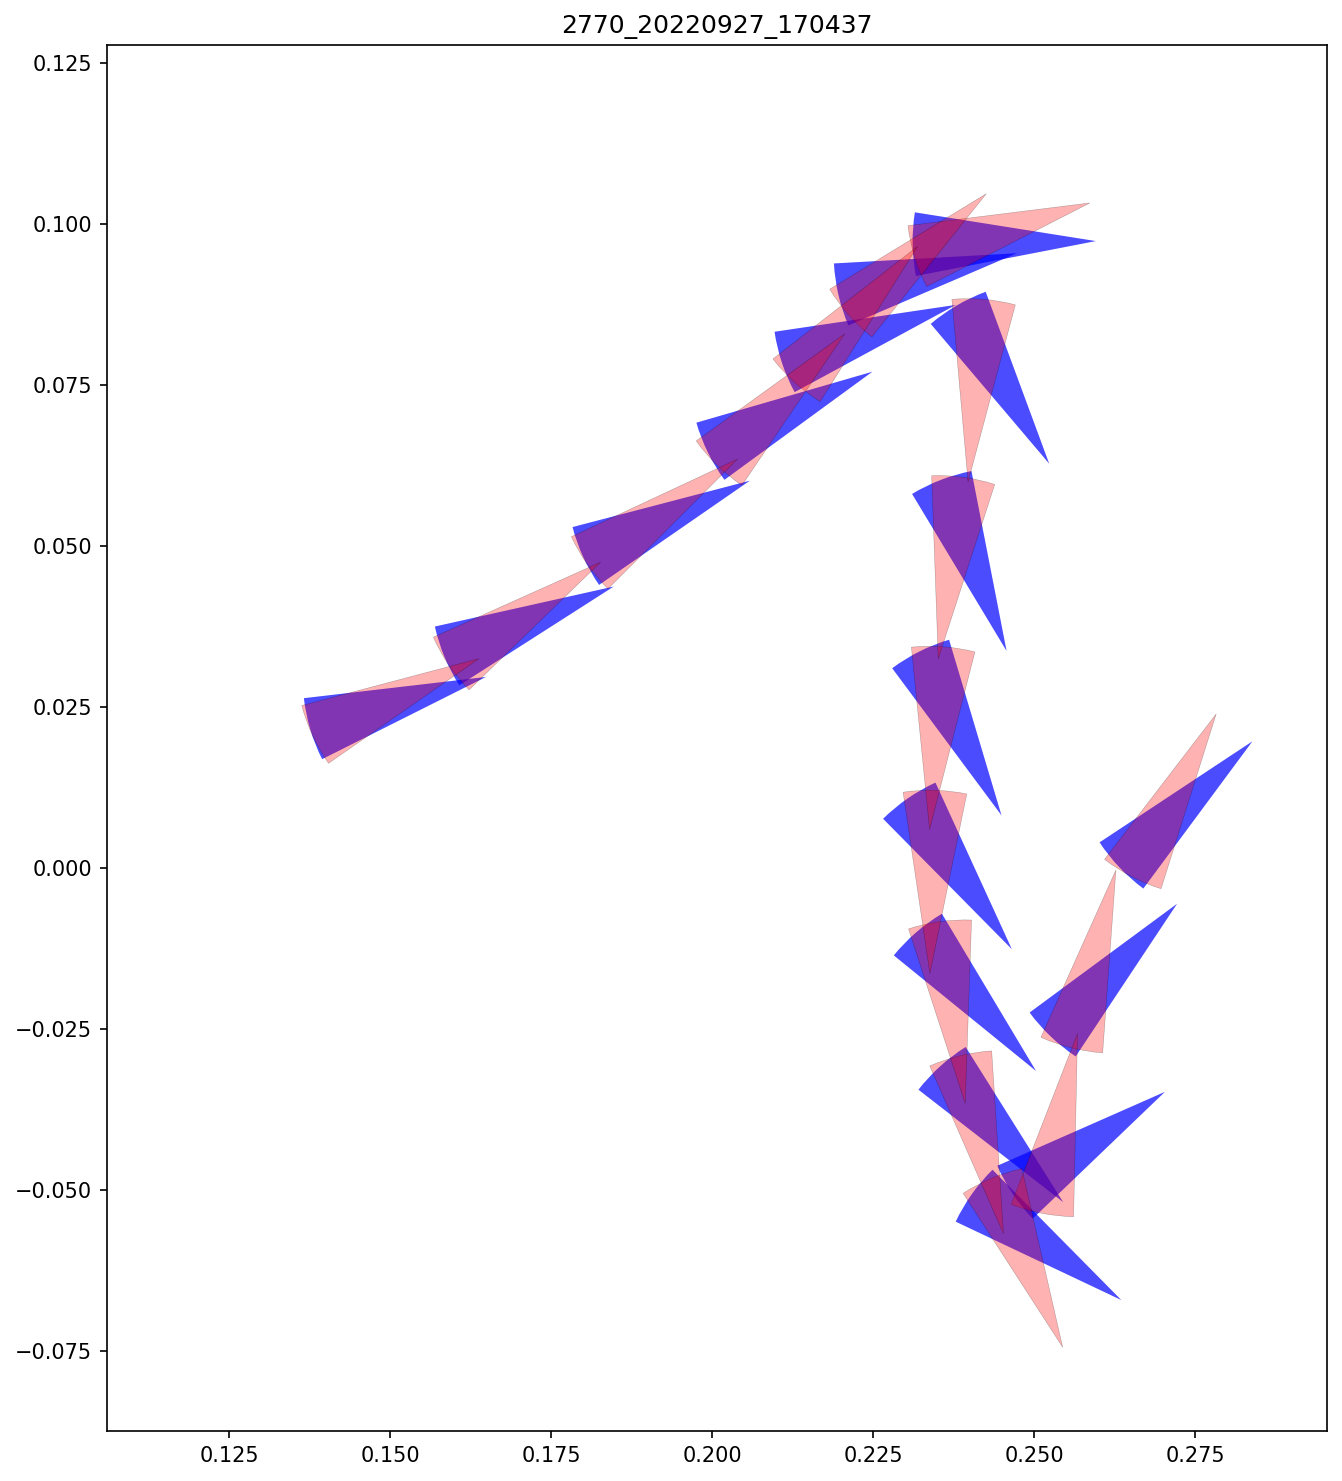

In [10]:
test_trajec_David = David_fly_data.loc[David_fly_data["trajec_objid"] == "2770_20220927_170437"]

fig, ax = plt.subplots(figsize=(12, 12), dpi=150)
plot_trajectory_with_predicted_heading(test_trajec_David[250:400], ax, n_input, ann_model,
    include_id=True, nskip=8, smooth=True, **david_kwargs)

os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/fig_2_panel_B_new_model.svg', format='svg', bbox_inches='tight')
plt.show()